In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

In [3]:
# Date range
now = dt.datetime.now() - dt.timedelta(days=1)
start = now - dt.timedelta(days=365*3)
start = start.strftime('%Y-%m-%d')

# Tickers of assets
assets = ["SPY", "QQQM", "277630.KS", "272910.KS", "IMTB"]
assets.sort()
# Downloading data
data = yf.download(assets, start = start, end = now)
data = data.loc[:,('Close', slice(None))]
data.columns = assets

[*********************100%***********************]  5 of 5 completed


In [4]:
# Calculating returns
Y = data[assets].pct_change().dropna()
display(Y.head())

,272910.KS,277630.KS,IMTB,QQQM,SPY
Date,,,,,
2022-08-30,-0.0847%,1.0004%,-0.0112%,-1.1020%,-1.0978%
2022-08-31,-0.2120%,0.6933%,-0.4030%,-0.5087%,-0.7609%
2022-09-01,-0.1434%,-2.1444%,-0.7481%,-0.0406%,0.3138%
2022-09-02,0.1010%,-0.2212%,0.5812%,-1.3477%,-1.0544%
2022-09-05,0.4091%,-0.2418%,0.0000%,0.0000%,0.0000%


In [5]:
import riskfolio as rp

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimal portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

# Estimate optimal portfolio:

model='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'MV' # Risk measure used, this time will be variance
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,272910.KS,277630.KS,IMTB,QQQM,SPY
weights,88.8451%,2.9054%,0.8288%,5.4840%,1.9367%


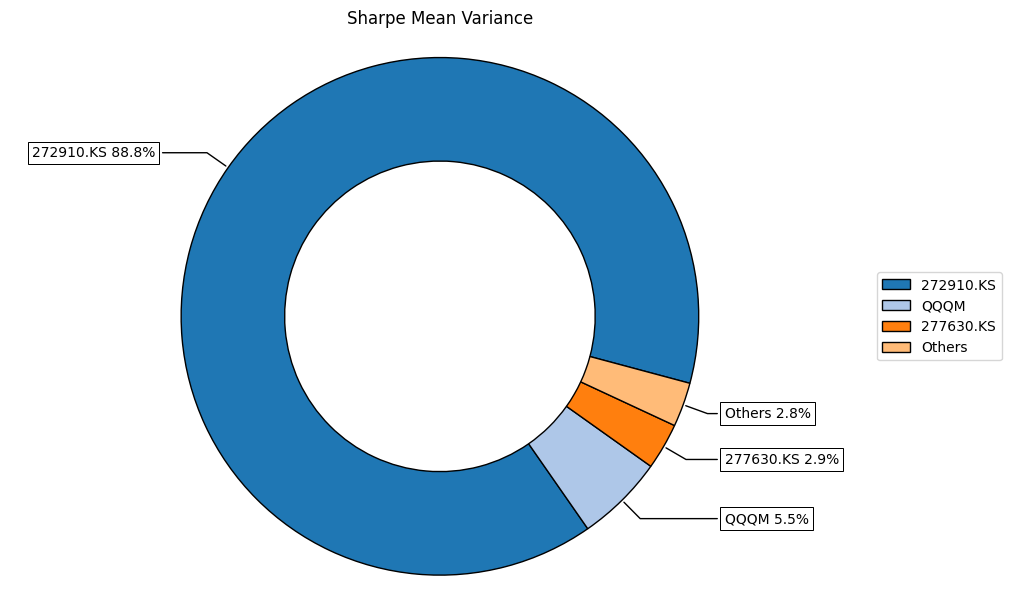

In [6]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w, title='Sharpe Mean Variance', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [7]:
points = 10 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())

,272910.KS,277630.KS,IMTB,QQQM,SPY
0,90.4171%,0.0000%,8.3271%,0.0000%,1.2558%
1,73.9769%,8.7023%,0.0000%,17.3207%,0.0000%
2,58.6406%,14.2458%,0.0000%,27.1136%,0.0000%
3,44.2869%,19.4357%,0.0000%,36.2774%,0.0000%
4,30.3019%,24.4870%,0.0000%,45.2111%,0.0000%


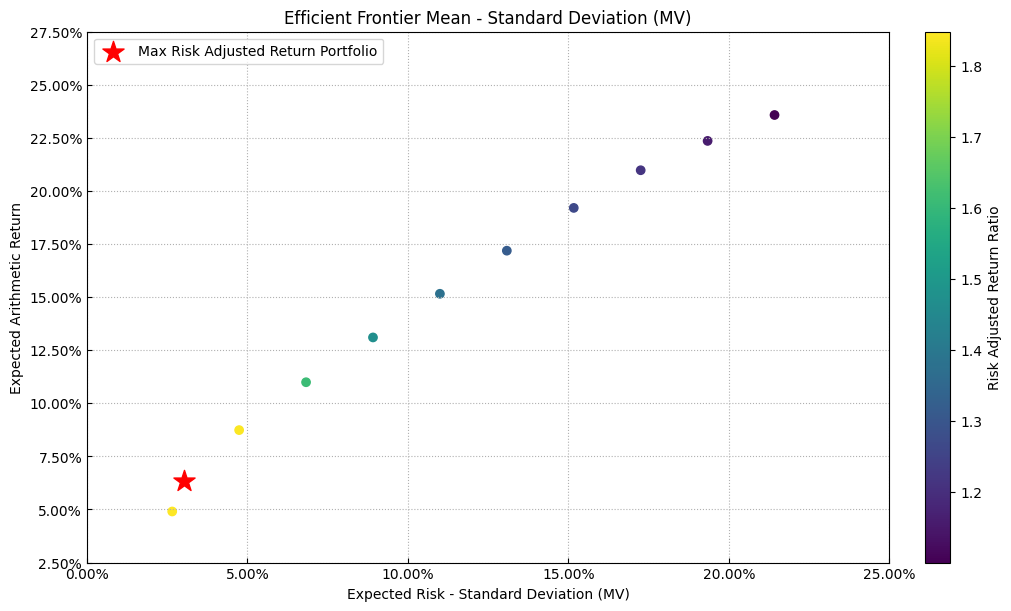

In [8]:
label = 'Max Risk Adjusted Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(w_frontier=frontier, mu=mu, cov=cov, returns=returns, rm=rm,
                      rf=rf, alpha=0.05, cmap='viridis', w=w, label=label,
                      marker='*', s=16, c='r', height=6, width=10, ax=None)

In [9]:
rm = 'CVaR' # Risk measure

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,272910.KS,277630.KS,IMTB,QQQM,SPY
weights,84.5252%,3.9530%,2.1028%,9.4191%,0.0000%


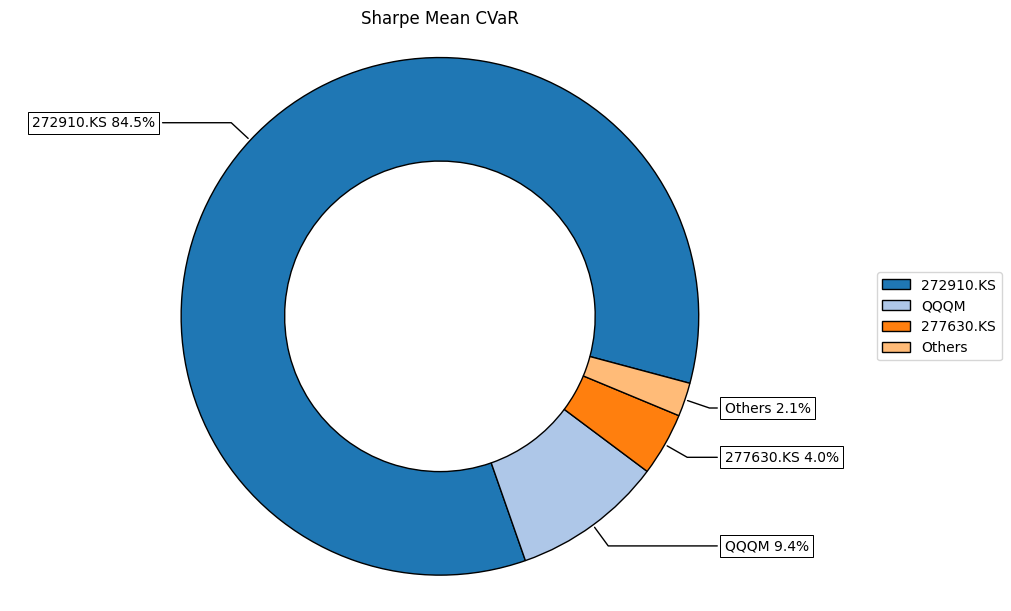

In [10]:
ax = rp.plot_pie(w=w, title='Sharpe Mean CVaR', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [11]:
# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'MAD': Mean Absolute Deviation.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.
rms = ['MV', 'MAD', 'MSV', 'FLPM', 'SLPM', 'CVaR',
       'EVaR', 'WR', 'MDD', 'ADD', 'CDaR', 'UCI', 'EDaR']

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=model, rm=i, obj=obj, rf=rf, l=l, hist=hist)
    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = rms
w_s.style.format("{:.2%}").background_gradient(cmap='YlGn')

,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
272910.KS,88.85%,91.97%,88.39%,91.65%,88.10%,84.53%,86.47%,76.23%,68.15%,92.06%,75.87%,88.67%,74.39%
277630.KS,2.91%,2.61%,2.70%,2.49%,2.75%,3.95%,1.89%,8.52%,19.89%,2.28%,13.97%,4.29%,13.71%
IMTB,0.83%,0.00%,1.47%,0.36%,1.61%,2.10%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
QQQM,5.48%,2.40%,6.48%,3.44%,6.99%,9.42%,11.64%,15.25%,11.96%,5.18%,5.31%,2.27%,11.90%
SPY,1.94%,3.02%,0.96%,2.06%,0.55%,0.00%,0.00%,0.00%,0.00%,0.49%,4.85%,4.78%,0.00%


[추천 포트폴리오] 위험 성향 1
- 예상 연수익률: 4.90%
- 예상 연변동성: 2.68%
- 샤프지수(무위험 0.00%): 1.83
- 과거 구간 기준 최대낙폭: -4.28%
- 비중 상위:
  · 272910.KS: 84.87%
  · IMTB: 13.31%
  · SPY: 1.46%
- 변동성 기여 상위:
  · 272910.KS: 80.67%
  · IMTB: 17.12%


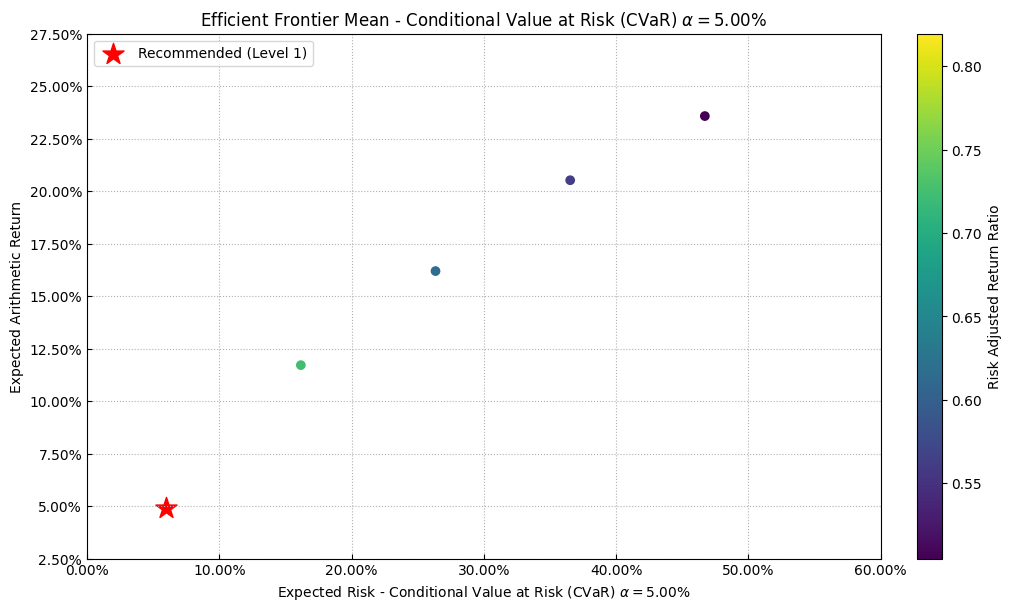

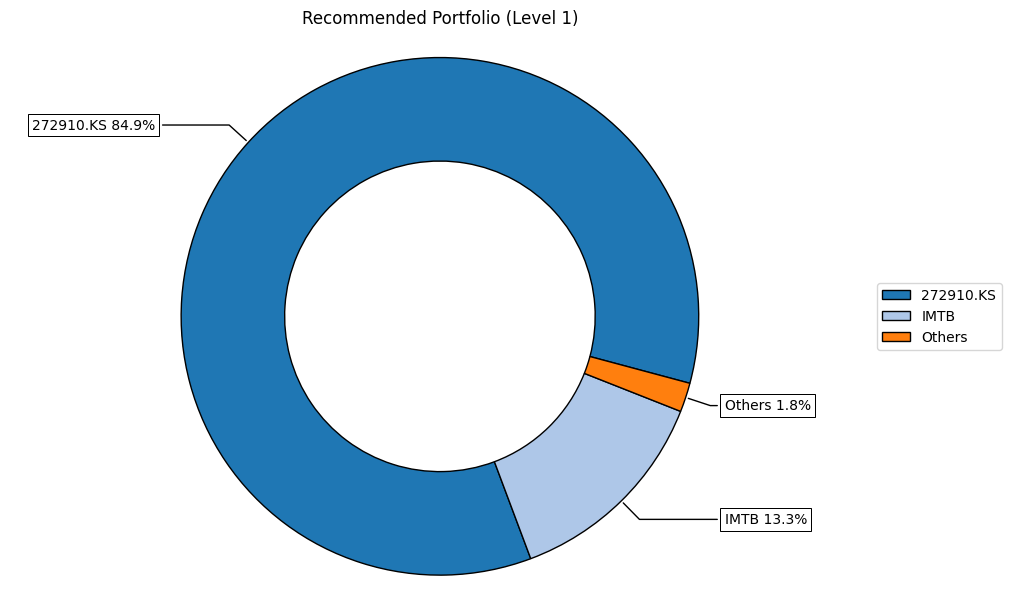

In [12]:
import numpy as np
import pandas as pd
import riskfolio as rp
import matplotlib.pyplot as plt

def recommend_portfolio(Y, risk_level=3, points=11, rf=0.0, plot_frontier=True, plot_pie=True):
    # 1) 성향→리스크측도/프론티어 위치 매핑
    rm = 'CVaR' if int(risk_level) == 1 else 'MV'
    idx_map = {1:0, 2:2, 3:5, 4:8, 5:10}
    idx = idx_map.get(int(risk_level), 5)
    idx = max(0, min(points-1, idx))

    # 2) 포트폴리오 최적화(효율적 경계선)
    port = rp.Portfolio(returns=Y)
    port.assets_stats(method_mu='hist', method_cov='hist')
    frontier = port.efficient_frontier(model='Classic', rm=rm, points=points, rf=rf, hist=True)
    w = frontier.iloc[:, idx].copy()  # 선택 포인트의 가중치 Series

    # 3) 성과·위험 지표(연환산) 및 설명
    ret = (Y @ w).rename('ret')
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = dd.min()

    # 리스크 기여(분산 기여 비중 기준)
    cov = Y.cov()
    w_aligned = w.reindex(cov.index).fillna(0.0).values
    sigma_w = cov.values @ w_aligned
    rc = w_aligned * sigma_w  # variance contribution
    rc_share = rc / rc.sum() if rc.sum() != 0 else rc
    rc_share = pd.Series(rc_share, index=cov.index).sort_values(ascending=False)

    # 4) 결과 출력(한글 설명은 텍스트, 그래프 라벨/타이틀은 영어)
    print(f"[추천 포트폴리오] 위험 성향 {risk_level}")
    print(f"- 예상 연수익률: {ann_ret:.2%}")
    print(f"- 예상 연변동성: {ann_vol:.2%}")
    print(f"- 샤프지수(무위험 {rf:.2%}): {sharpe:.2f}")
    print(f"- 과거 구간 기준 최대낙폭: {mdd:.2%}")

    top_w = w.sort_values(ascending=False).head(3)
    print("- 비중 상위:")
    for k, v in top_w.items():
        print(f"  · {k}: {v:.2%}")

    top_rc = rc_share.head(2)
    print("- 변동성 기여 상위:")
    for k, v in top_rc.items():
        print(f"  · {k}: {v:.2%}")

    if plot_frontier:
        _ = rp.plot_frontier(
            w_frontier=frontier, mu=port.mu, cov=port.cov, returns=port.returns,
            rm=rm, rf=rf, alpha=0.05, cmap='viridis',
            w=w, label=f"Recommended (Level {risk_level})",
            marker='*', s=16, c='r', height=6, width=10, ax=None
        )
        plt.show()
    if plot_pie:
        _ = rp.plot_pie(
            w=w, title=f"Recommended Portfolio (Level {risk_level})",
            others=0.05, nrow=25, cmap="tab20", height=6, width=10, ax=None
        )
        plt.show()
    return w, {
        "risk_level": risk_level,
        "rm": rm,
        "annual_return": ann_ret,
        "annual_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": mdd
    }

# 사용 예시:
w, summary = recommend_portfolio(Y, risk_level=1, points=5, rf=0.0, plot_frontier=True, plot_pie=True)

In [13]:
w, summary = recommend_portfolio(Y, risk_level=1, points=5, rf=0.0, plot=True)

TypeError: recommend_portfolio() got an unexpected keyword argument 'plot'

[추천 포트폴리오] 위험 성향 2
- 예상 연수익률: 16.17%
- 예상 연변동성: 12.04%
- 샤프지수(무위험 0.00%): 1.34
- 과거 구간 기준 최대낙폭: -14.40%
- 비중 상위:
  · QQQM: 49.63%
  · 277630.KS: 26.99%
  · 272910.KS: 23.38%
- 변동성 기여 상위:
  · QQQM: 80.99%
  · 277630.KS: 18.26%


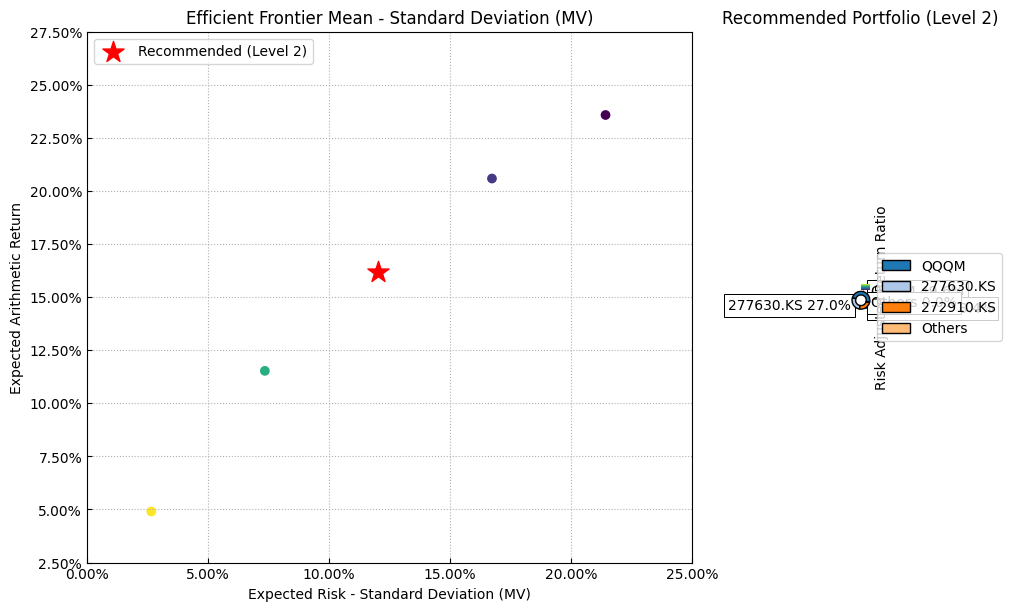

In [47]:
w, summary = recommend_portfolio(Y, risk_level=2, points=5, rf=0.0, plot=True)

[추천 포트폴리오] 위험 성향 3
- 예상 연수익률: 23.58%
- 예상 연변동성: 21.43%
- 샤프지수(무위험 0.00%): 1.10
- 과거 구간 기준 최대낙폭: -22.70%
- 비중 상위:
  · QQQM: 100.00%
  · SPY: 0.00%
  · 277630.KS: 0.00%
- 변동성 기여 상위:
  · QQQM: 100.00%
  · SPY: 0.00%


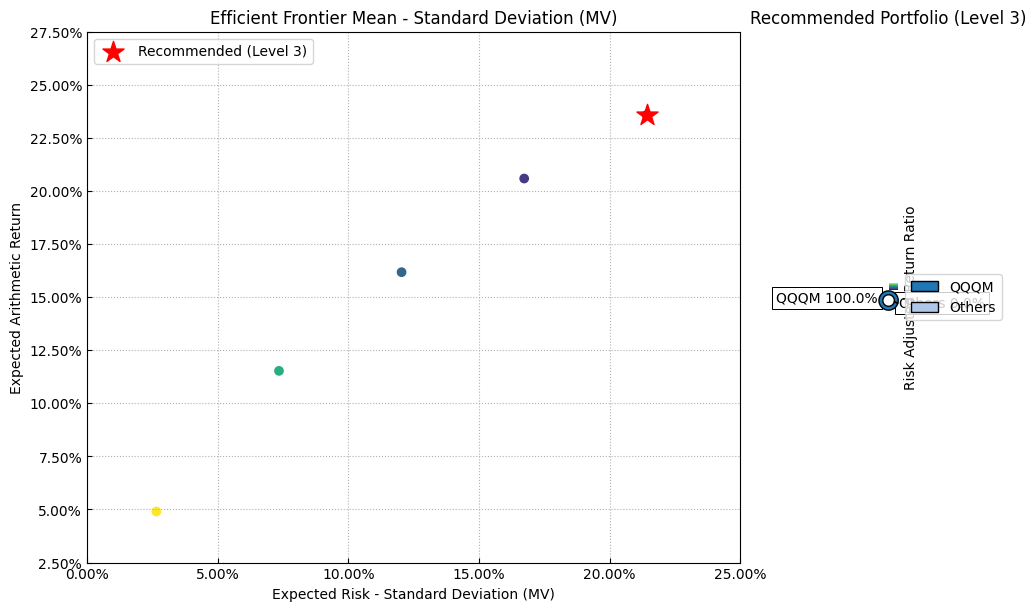

In [48]:
w, summary = recommend_portfolio(Y, risk_level=3, points=5, rf=0.0, plot=True)

[추천 포트폴리오] 위험 성향 4
- 예상 연수익률: 23.58%
- 예상 연변동성: 21.43%
- 샤프지수(무위험 0.00%): 1.10
- 과거 구간 기준 최대낙폭: -22.70%
- 비중 상위:
  · QQQM: 100.00%
  · SPY: 0.00%
  · 277630.KS: 0.00%
- 변동성 기여 상위:
  · QQQM: 100.00%
  · SPY: 0.00%


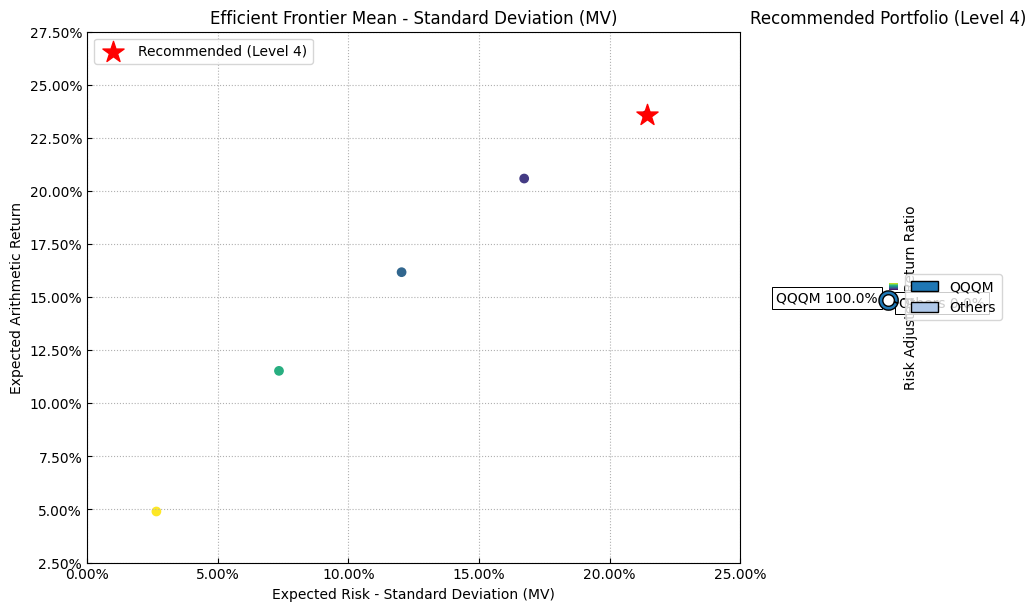

In [49]:
w, summary = recommend_portfolio(Y, risk_level=4, points=5, rf=0.0, plot=True)

[추천 포트폴리오] 위험 성향 5
- 예상 연수익률: 23.58%
- 예상 연변동성: 21.43%
- 샤프지수(무위험 0.00%): 1.10
- 과거 구간 기준 최대낙폭: -22.70%
- 비중 상위:
  · QQQM: 100.00%
  · SPY: 0.00%
  · 277630.KS: 0.00%
- 변동성 기여 상위:
  · QQQM: 100.00%
  · SPY: 0.00%


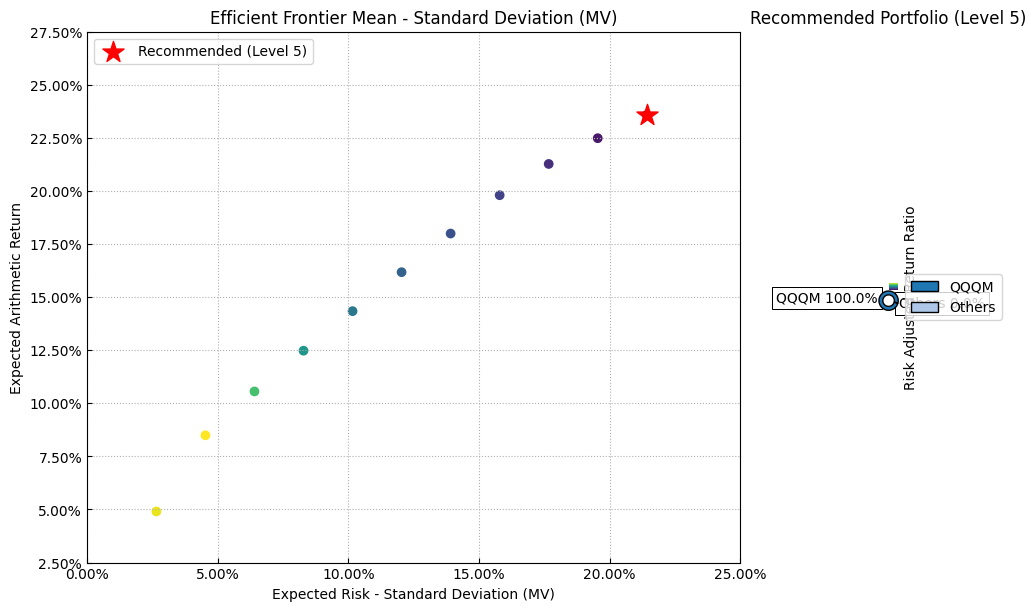

In [ ]:
w, summary = recommend_portfolio(Y, risk_level=5, points=11, rf=0.0, plot=True)

In [14]:
import matplotlib.pyplot as plt

def recommend_portfolio(Y, risk_level=3, points=11, rf=0.0, plot=True):
    # 1) 성향→리스크측도/프론티어 위치 매핑
    rm = 'CVaR' if int(risk_level) == 1 else 'MV'
    idx_map = {1:0, 2:2, 3:5, 4:8, 5:10}
    idx = idx_map.get(int(risk_level), 5)
    idx = max(0, min(points-1, idx))

    # 2) 포트폴리오 최적화(효율적 경계선)
    port = rp.Portfolio(returns=Y)
    port.assets_stats(method_mu='hist', method_cov='hist')
    frontier = port.efficient_frontier(model='Classic', rm=rm, points=points, rf=rf, hist=True)
    w = frontier.iloc[:, idx].copy()

    # 3) 성과·위험 지표(연환산) 및 설명
    ret = (Y @ w).rename('ret')
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = dd.min()

    # 리스크 기여(분산 기여 비중 기준)
    cov = Y.cov()
    w_aligned = w.reindex(cov.index).fillna(0.0).values
    sigma_w = cov.values @ w_aligned
    rc = w_aligned * sigma_w
    rc_share = rc / rc.sum() if rc.sum() != 0 else rc
    rc_share = pd.Series(rc_share, index=cov.index).sort_values(ascending=False)

    # 4) 결과 출력(한글 설명은 텍스트, 그래프 라벨/타이틀은 영어)
    print(f"[추천 포트폴리오] 위험 성향 {risk_level}")
    print(f"- 예상 연수익률: {ann_ret:.2%}")
    print(f"- 예상 연변동성: {ann_vol:.2%}")
    print(f"- 샤프지수(무위험 {rf:.2%}): {sharpe:.2f}")
    print(f"- 과거 구간 기준 최대낙폭: {mdd:.2%}")

    top_w = w.sort_values(ascending=False).head(3)
    print("- 비중 상위:")
    for k, v in top_w.items():
        print(f"  · {k}: {v:.2%}")

    top_rc = rc_share.head(2)
    print("- 변동성 기여 상위:")
    for k, v in top_rc.items():
        print(f"  · {k}: {v:.2%}")

    if plot:
        fig1, ax1 = plt.subplots(figsize=(10, 6))
        _ = rp.plot_frontier(
            w_frontier=frontier, mu=port.mu, cov=port.cov, returns=port.returns,
            rm=rm, rf=rf, alpha=0.05, cmap='viridis',
            w=w, label=f"Recommended (Level {risk_level})",
            marker='*', s=16, c='r', ax=ax1
        )
        plt.show()

        fig2, ax2 = plt.subplots(figsize=(10, 6))
        _ = rp.plot_pie(
            w=w, title=f"Recommended Portfolio (Level {risk_level})",
            others=0.03, nrow=25, cmap="tab20", ax=ax2
        )
        plt.show()

    return w, {
        "risk_level": risk_level,
        "rm": rm,
        "annual_return": ann_ret,
        "annual_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": mdd
    }


[추천 포트폴리오] 위험 성향 3
- 예상 연수익률: 16.17%
- 예상 연변동성: 12.04%
- 샤프지수(무위험 0.00%): 1.34
- 과거 구간 기준 최대낙폭: -14.40%
- 비중 상위:
  · QQQM: 49.63%
  · 277630.KS: 26.99%
  · 272910.KS: 23.38%
- 변동성 기여 상위:
  · QQQM: 80.99%
  · 277630.KS: 18.26%


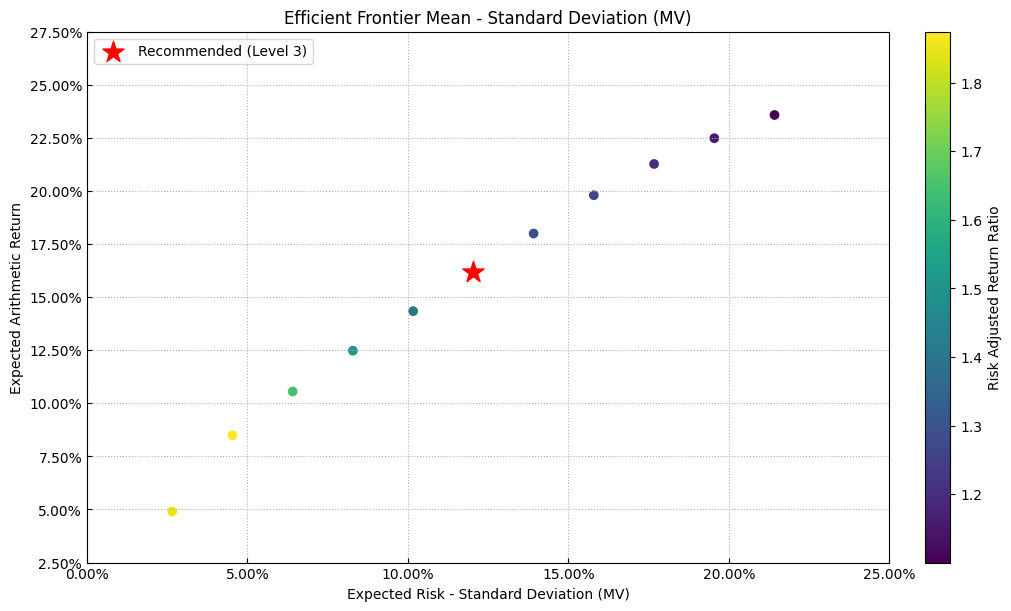

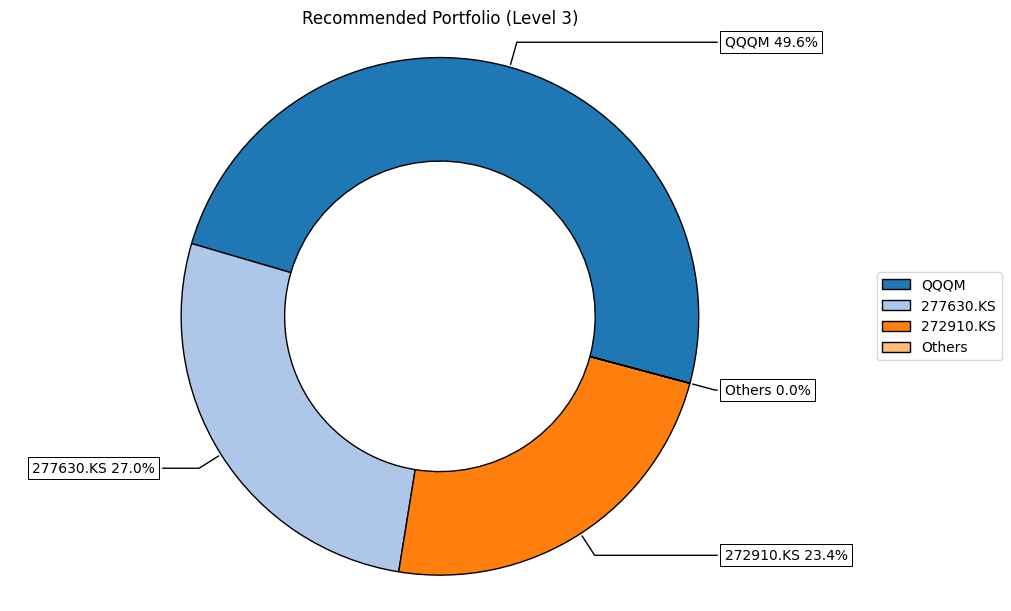

In [25]:
w, summary = recommend_portfolio(Y, risk_level=3, points=11, rf=0.0, plot=True)